# 01 · D3TaLES 还原电位数据审计

这本 Notebook 只做数据检查和统计，不生成最终训练数据，也不决定重复值阈值。请从上到下逐格运行；如果某一格报错，先停止并保留完整报错信息。

## 单元格 1：导入依赖并定位项目目录

作用：导入数据分析、绘图和 RDKit，并自动判断 Notebook 是从项目根目录还是 `notebooks` 目录启动。此单元格不会读取或修改数据。

In [1]:
# 标准库：路径、文件哈希、JSON 和版本信息
from pathlib import Path
import hashlib
import json
import platform

# 数据分析和绘图
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 分子解析、Canonical SMILES 和 Murcko scaffold
from rdkit import Chem, rdBase
from rdkit.Chem.Scaffolds import MurckoScaffold

# 无论从项目根目录还是 notebooks 目录打开，都定位到 myJCIM 根目录
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR

print('Python:', platform.python_version())
print('pandas:', pd.__version__)
print('RDKit:', rdBase.rdkitVersion)
print('项目根目录:', PROJECT_ROOT)

Python: 3.10.21
pandas: 2.3.3
RDKit: 2022.09.5
项目根目录: E:\desktop\myJCIM


## 单元格 2：设置输入和输出路径

作用：指定原始 CSV 的标准位置，并创建报告目录。运行前请把最新版数据复制为 `data/raw/d3tales_public.csv`。这里不会自动复制或覆盖原始数据。

In [2]:
# 原始数据只读路径；后续所有中间结果写入 reports，不修改该文件
RAW_CSV = PROJECT_ROOT / 'data' / 'raw' / 'd3tales_public.csv'
REPORT_DATA_DIR = PROJECT_ROOT / 'reports' / 'data'
REPORT_FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'

# 报告目录不存在时创建；exist_ok=True 不会覆盖已有文件
REPORT_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if not RAW_CSV.exists():
    raise FileNotFoundError(
        f'没有找到 {RAW_CSV}。请先把最新版 D3TaLES CSV 复制到 data/raw。'
    )

print('输入文件:', RAW_CSV)
print('文件大小(MB):', round(RAW_CSV.stat().st_size / 1024**2, 2))

输入文件: E:\desktop\myJCIM\data\raw\d3tales_public.csv
文件大小(MB): 33.36


## 单元格 3：计算文件校验值并读取 CSV

作用：计算 SHA256，确保本地和服务器使用同一个原始文件；随后读取完整 CSV，展示规模和前几列名称。

In [3]:
# 分块读取文件计算 SHA256，避免一次性把二进制文件读入内存
sha256 = hashlib.sha256()
with RAW_CSV.open('rb') as file_handle:
    for chunk in iter(lambda: file_handle.read(1024 * 1024), b''):
        sha256.update(chunk)
raw_sha256 = sha256.hexdigest()

# low_memory=False 让 pandas 统一判断混合类型列，减少类型警告
df_raw = pd.read_csv(RAW_CSV, low_memory=False)

print('SHA256:', raw_sha256)
print('数据形状:', df_raw.shape)
print('前10个字段:', df_raw.columns[:10].tolist())
df_raw.head(3)

SHA256: 40dc15b8dd00800a23b4ad6f57456634c8163a237cd7cb32aafa9addb7db492d
数据形状: (35777, 98)
前10个字段: ['_id', 'public', 'smiles', 'source_group', 'groundState_charge', 'number_of_atoms', 'molecular_weight', 'sa_score', 'hole_reorganization_energy', 'electron_reorganization_energy']


,_id,public,smiles,source_group,groundState_charge,number_of_atoms,molecular_weight,sa_score,hole_reorganization_energy,electron_reorganization_energy,...,groundState.singlet_states,cation1.singlet_states,cation2.singlet_states,anion1.singlet_states,anion2.singlet_states,groundState.triplet_states,cation1.triplet_states,cation2.triplet_states,anion1.triplet_states,anion2.triplet_states
0,05QDYA,True,CN(C)c1c(N(C)C)[c+]1N(C)C,Odom_hussein,1.0,12.0,168.149524,4.35,NaN,3.409,...,1.8772,NaN,0.7168,NaN,3.1644,1.7788,1.2718,-1.2796,5.2088,1.7429
1,05RPNH,True,COc1ccc(N(c2ccc(OC)cc2)c2ccc(-c3ccc(N(c4ccc(OC...,Risko_Bayesian,0.0,46.0,608.267508,1.86,NaN,NaN,...,NaN,NaN,1.2545,NaN,1.1165,NaN,NaN,-0.9152,2.8676,-0.6957
2,05MXLE,True,CN(C)c1c(-c2ccc3c(c2)Sc2ccccc2S3)[c+]1N(C)C,Odom_hussein,1.0,23.0,339.098417,3.59,NaN,NaN,...,2.1270,NaN,0.0933,NaN,2.1165,1.9966,1.6511,-0.5282,NaN,0.5817


## 单元格 4：检查关键字段

作用：确认本研究必需的 ID、SMILES、电荷、来源和还原电位字段都存在；任一字段缺失都会立即停止，避免后面静默使用错误数据。

In [4]:
# 只检查当前研究必需的字段，不把 DFT 中间量纳入模型输入
REQUIRED_COLUMNS = [
    '_id',
    'smiles',
    'source_group',
    'groundState_charge',
    'reduction_potential',
    'solv_reduction_potential',
]
missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df_raw.columns))
assert not missing_columns, f'缺少关键字段: {missing_columns}'

print('关键字段检查通过。')
df_raw[REQUIRED_COLUMNS].info()

关键字段检查通过。
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35777 entries, 0 to 35776
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   _id                       35777 non-null  object 
 1   smiles                    35777 non-null  object 
 2   source_group              35726 non-null  object 
 3   groundState_charge        35729 non-null  float64
 4   reduction_potential       30356 non-null  float64
 5   solv_reduction_potential  30356 non-null  float64
dtypes: float64(3), object(3)
memory usage: 1.6+ MB


## 单元格 5：核对两个还原电位字段

作用：统计 `reduction_potential` 和 `solv_reduction_potential` 的非空数，并验证共同非空位置是否完全一致。这一步只核对，不改变目标字段。

In [5]:
# 仅在两个字段都非空的行上计算差值
both_targets = df_raw[['reduction_potential', 'solv_reduction_potential']].dropna()
target_abs_diff = (
    both_targets['reduction_potential']
    - both_targets['solv_reduction_potential']
).abs()

target_check = pd.Series({
    'reduction_non_null': int(df_raw['reduction_potential'].notna().sum()),
    'solv_reduction_non_null': int(df_raw['solv_reduction_potential'].notna().sum()),
    'both_non_null': int(len(both_targets)),
    'maximum_absolute_difference': float(target_abs_diff.max()) if len(target_abs_diff) else None,
})
target_check

reduction_non_null             30356.0
solv_reduction_non_null        30356.0
both_non_null                  30356.0
maximum_absolute_difference        0.0
dtype: float64

## 单元格 6：筛选目标非空和中性分子

作用：构造本研究的候选样本集，并记录每一步剩余数量。这里只在内存中筛选，不保存最终数据。

In [6]:
# 第一步：保留具有主任务标签的分子
df_target = df_raw.loc[df_raw['reduction_potential'].notna()].copy()

# 第二步：只保留基态电荷为 0 的中性分子
df_neutral = df_target.loc[df_target['groundState_charge'].eq(0)].copy()

data_flow = [
    {'step': 'raw_rows', 'remaining': int(len(df_raw))},
    {'step': 'reduction_potential_not_null', 'remaining': int(len(df_target))},
    {'step': 'neutral_ground_state', 'remaining': int(len(df_neutral))},
]

pd.DataFrame(data_flow)

,step,remaining
0,raw_rows,35777
1,reduction_potential_not_null,30356
2,neutral_ground_state,30145


## 单元格 7：解析 SMILES 并生成 Canonical SMILES

作用：使用 RDKit 检查 SMILES 是否有效，并把同一分子的不同写法统一为 Canonical SMILES。

In [7]:
# 将一个 SMILES 转换为 Canonical SMILES；无效或缺失时返回 None
def to_canonical_smiles(smiles):
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        return None
    return Chem.MolToSmiles(molecule, canonical=True, isomericSmiles=True)

# 在中性、目标非空的候选集中执行解析
df_neutral['canonical_smiles'] = df_neutral['smiles'].map(to_canonical_smiles)
valid_smiles_mask = df_neutral['canonical_smiles'].notna()
df_valid = df_neutral.loc[valid_smiles_mask].copy()

data_flow.append({
    'step': 'valid_smiles',
    'remaining': int(len(df_valid)),
})

print('无效SMILES数量:', int((~valid_smiles_mask).sum()))
pd.DataFrame(data_flow)

无效SMILES数量: 0


,step,remaining
0,raw_rows,35777
1,reduction_potential_not_null,30356
2,neutral_ground_state,30145
3,valid_smiles,30145


## 单元格 8：统计重复分子及目标差异

作用：按照 Canonical SMILES 聚合，计算每组的记录数、均值、标准差、最小值、最大值和极差。这里不删除任何重复组。

In [8]:
# 聚合同一 Canonical SMILES 的还原电位
duplicate_stats = (
    df_valid.groupby('canonical_smiles', as_index=False)
    .agg(
        count=('reduction_potential', 'size'),
        target_mean=('reduction_potential', 'mean'),
        target_std=('reduction_potential', 'std'),
        target_min=('reduction_potential', 'min'),
        target_max=('reduction_potential', 'max'),
    )
)
duplicate_stats['target_range'] = (
    duplicate_stats['target_max'] - duplicate_stats['target_min']
)
duplicate_groups = duplicate_stats.loc[duplicate_stats['count'] > 1].copy()

duplicate_summary = pd.Series({
    'valid_rows': int(len(df_valid)),
    'unique_canonical_smiles': int(df_valid['canonical_smiles'].nunique()),
    'duplicate_groups': int(len(duplicate_groups)),
    'extra_duplicate_rows': int(len(df_valid) - df_valid['canonical_smiles'].nunique()),
    'maximum_duplicate_target_range': (
        float(duplicate_groups['target_range'].max()) if len(duplicate_groups) else 0.0
    ),
})
duplicate_summary

valid_rows                        30145.000
unique_canonical_smiles           30117.000
duplicate_groups                     27.000
extra_duplicate_rows                 28.000
maximum_duplicate_target_range        1.215
dtype: float64

## 单元格 9：查看重复值差异最大的分子

作用：按目标极差从大到小展示重复组，供我们判断重复值是浮点误差、小幅差异还是明显冲突。

In [9]:
# 展示差异最大的前 30 个重复组，不在本单元格作删除决定
duplicate_groups.sort_values(
    ['target_range', 'count'], ascending=[False, False]
).head(30)

,canonical_smiles,count,target_mean,target_std,target_min,target_max,target_range
17461,C[C@@H]1[C@H](C)N(S(=O)(=O)CCc2ccccc2)CCS1(=O)=O,2,6.0775,0.859135,5.470,6.685,1.215
17302,C[C@@H]1CN([C@@H](NC(=O)c2ccco2)C(Cl)(Cl)Cl)C[...,2,6.6360,0.629325,6.191,7.081,0.890
16686,C[C@@H](NC(=O)[C@H](C)c1cccs1)c1ccc(Br)cc1,2,6.1350,0.554372,5.743,6.527,0.784
17931,C[C@H](NC(=O)Nc1ccccc1)C(=O)NC[C@H](C)Oc1ccccc1,2,5.2580,0.231931,5.094,5.422,0.328
18203,C[C@H]([C@H](C)S(C)(=O)=O)N(C)C(=O)c1cc(Cl)c2c...,2,6.5385,0.178898,6.412,6.665,0.253
21670,Cc1cccc(C)c1NC(=O)COC(=O)[C@H]1[C@@H]2C[C@@H]3...,2,5.9215,0.160513,5.808,6.035,0.227
17458,C[C@@H]1[C@H](C)CCC[C@H]1NC(=O)[C@@H](C)OC(=O)...,2,5.9750,0.130108,5.883,6.067,0.184
17460,C[C@@H]1[C@H](C)CCC[C@H]1n1c(CCl)nc2cccnc21,2,7.1565,0.112430,7.077,7.236,0.159
10419,CNC(=O)c1cccc(NCC(=O)N2[C@H](C)CCC[C@@H]2C)c1C,2,5.7915,0.106773,5.716,5.867,0.151
657,C=CCOc1c(CN2C[C@@H](C)S[C@@H](C)C2)c(C)nn1C,2,7.1095,0.070004,7.060,7.159,0.099


## 单元格 10：生成 Murcko scaffold

作用：为每个有效分子生成 Bemis–Murcko scaffold，并统计 scaffold 数量。无环分子可能得到空 scaffold，这是需要记录的正常情况，而不是立即删除。

In [10]:
# 从 Canonical SMILES 生成 scaffold；RDKit 已成功解析的分子理论上不会报错
def to_murcko_scaffold(canonical_smiles):
    molecule = Chem.MolFromSmiles(canonical_smiles)
    scaffold = MurckoScaffold.GetScaffoldForMol(molecule)
    return Chem.MolToSmiles(scaffold, canonical=True, isomericSmiles=True)

df_valid['murcko_scaffold'] = df_valid['canonical_smiles'].map(to_murcko_scaffold)
scaffold_counts = df_valid['murcko_scaffold'].value_counts(dropna=False)

scaffold_summary = pd.Series({
    'rows': int(len(df_valid)),
    'unique_scaffolds_including_empty': int(df_valid['murcko_scaffold'].nunique(dropna=False)),
    'empty_scaffold_rows': int(df_valid['murcko_scaffold'].eq('').sum()),
    'largest_scaffold_group': int(scaffold_counts.iloc[0]),
})
scaffold_summary

rows                                30145
unique_scaffolds_including_empty    15964
empty_scaffold_rows                     7
largest_scaffold_group               1696
dtype: int64

## 单元格 11：绘制审计图

作用：绘制目标值分布、重复组目标极差和 scaffold 大小分布，并保存到 `reports/figures`。这些图只用于制定清洗规则。

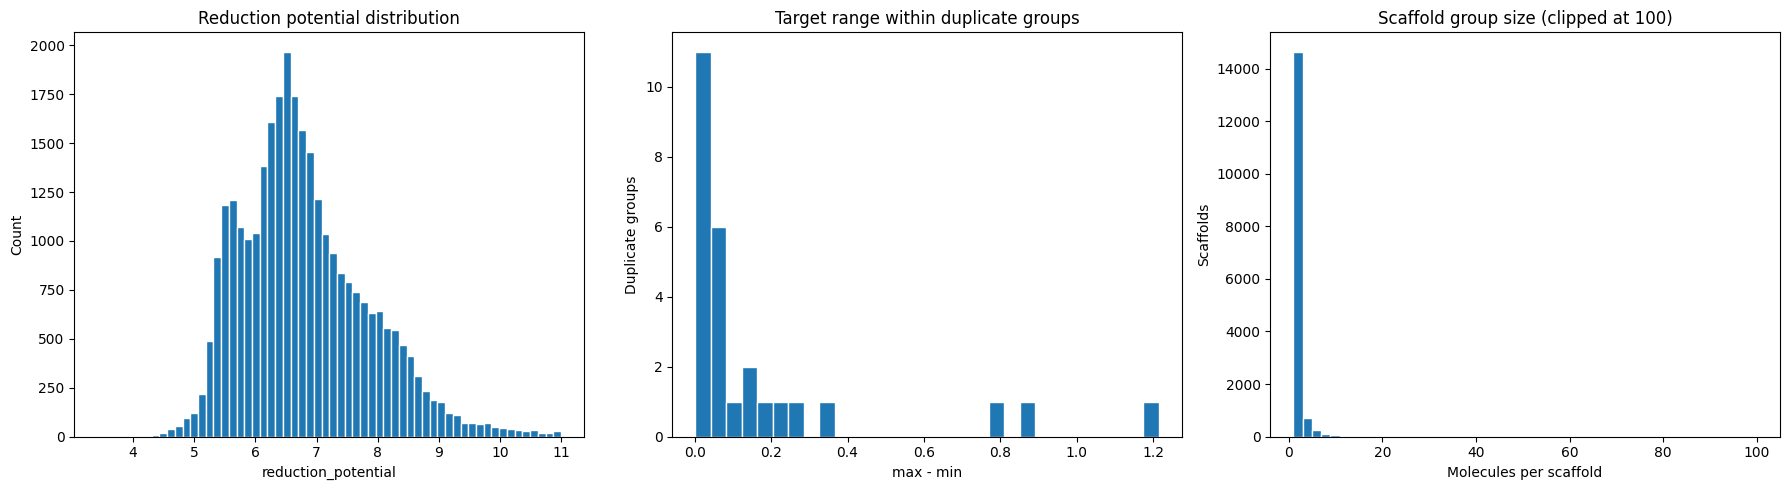

图片已保存: E:\desktop\myJCIM\reports\figures\d3tales_data_audit.png


In [11]:
# 创建三联图，便于同时判断目标分布、重复冲突和 scaffold 长尾
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_valid['reduction_potential'], bins=60, edgecolor='white')
axes[0].set_title('Reduction potential distribution')
axes[0].set_xlabel('reduction_potential')
axes[0].set_ylabel('Count')

if len(duplicate_groups):
    axes[1].hist(duplicate_groups['target_range'], bins=30, edgecolor='white')
axes[1].set_title('Target range within duplicate groups')
axes[1].set_xlabel('max - min')
axes[1].set_ylabel('Duplicate groups')

axes[2].hist(scaffold_counts.clip(upper=100), bins=50, edgecolor='white')
axes[2].set_title('Scaffold group size (clipped at 100)')
axes[2].set_xlabel('Molecules per scaffold')
axes[2].set_ylabel('Scaffolds')

fig.tight_layout()
figure_path = REPORT_FIGURE_DIR / 'd3tales_data_audit.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
plt.show()
print('图片已保存:', figure_path)

## 单元格 12：统计数据来源与目标描述

作用：检查候选数据由哪些 `source_group` 构成，并输出还原电位的描述统计，帮助后续识别来源偏差。

In [12]:
# 来源分布和目标统计均基于：标签非空、中性、SMILES有效的候选集
source_distribution = (
    df_valid['source_group']
    .fillna('MISSING')
    .value_counts()
    .rename_axis('source_group')
    .reset_index(name='count')
)

display(df_valid['reduction_potential'].describe())
source_distribution

count    30145.000000
mean         6.798525
std          1.039633
min          3.418000
25%          6.077000
50%          6.641000
75%          7.410000
max         11.000000
Name: reduction_potential, dtype: float64

,source_group,count
0,Zinc,23292
1,csd,4201
2,Risko,1646
3,Risko_Bayesian,806
4,Risko_benchmark,106
5,Odom_hussein,26
6,Odom_aman,20
7,Ganapathysubramanian,20
8,Risko_Aman,19
9,NonD3tales,4


## 单元格 13：保存审计结果

作用：只保存统计报告和重复组明细，不导出最终清洗数据。运行后把输出数字和图发给我，我们再共同确定去重规则。

In [13]:
# 把逐步样本量补充为包含删除数量的流程表
data_flow_df = pd.DataFrame(data_flow)
data_flow_df['removed_from_previous'] = (
    data_flow_df['remaining'].shift(1) - data_flow_df['remaining']
).fillna(0).astype(int)

# 汇总成可被版本管理和程序读取的 JSON
audit_summary = {
    'raw_file': str(RAW_CSV),
    'raw_sha256': raw_sha256,
    'raw_rows': int(len(df_raw)),
    'raw_columns': int(df_raw.shape[1]),
    'target_check': target_check.to_dict(),
    'duplicate_summary': duplicate_summary.to_dict(),
    'scaffold_summary': scaffold_summary.to_dict(),
    'python_version': platform.python_version(),
    'pandas_version': pd.__version__,
    'rdkit_version': rdBase.rdkitVersion,
}

# 只写审计产物；不修改原始CSV，也不创建最终建模数据
data_flow_df.to_csv(REPORT_DATA_DIR / 'd3tales_data_flow.csv', index=False)
duplicate_groups.sort_values('target_range', ascending=False).to_csv(
    REPORT_DATA_DIR / 'd3tales_duplicate_groups.csv', index=False
)
source_distribution.to_csv(
    REPORT_DATA_DIR / 'd3tales_source_distribution.csv', index=False
)
with (REPORT_DATA_DIR / 'd3tales_data_audit.json').open('w', encoding='utf-8') as file_handle:
    json.dump(audit_summary, file_handle, ensure_ascii=False, indent=2)

display(data_flow_df)
print('审计报告目录:', REPORT_DATA_DIR)
print('本 Notebook 到此停止：尚未去重、划分或生成训练数据。')

,step,remaining,removed_from_previous
0,raw_rows,35777,0
1,reduction_potential_not_null,30356,5421
2,neutral_ground_state,30145,211
3,valid_smiles,30145,0


审计报告目录: E:\desktop\myJCIM\reports\data
本 Notebook 到此停止：尚未去重、划分或生成训练数据。


## 运行完成后请提供这些结果

请把下面内容发给我：

1. 单元格 5 的 `target_check`；
2. 单元格 7 的无效 SMILES 数量；
3. 单元格 8 的 `duplicate_summary`；
4. 单元格 9 显示的重复组前 30 行；
5. 单元格 10 的 `scaffold_summary`；
6. `reports/figures/d3tales_data_audit.png`。

在检查这些结果之前，不执行最终去重，也不生成 Scaffold Split。